# Demo chạy thực nghiệm và So sánh 3 Kiến trúc (U-Net vs DeepLabV3+ Gốc vs Copy-Paste)

Script này dùng để nạp các file trọng số `.pth` đã train để thử nghiệm dự đoán trên ảnh mới và sinh Heatmap Grad-CAM so sánh.
Lưu ý: Phục vụ tốt cho việc chạy làm Demo Video cho giảng viên.

In [21]:
import os
import sys
import torch

sys.path.append("..")
from models.builder import build_model
from dataset.pascal_voc import NUM_CLASSES
from extensions.gradcam_eval import compare_gradcam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Load các Models đã được huấn luyện


In [22]:
models_dict = {}

# 1. U-Net Gốc
unet = build_model("unet", "resnet50", NUM_CLASSES, None).to(device)
unet_path = "../checkpoints/unet_resnet50_voc_best.pth"
if os.path.exists(unet_path):
    unet.load_state_dict(
        torch.load(unet_path, map_location=device, weights_only=False)[
            "model_state_dict"
        ]
    )
    unet.eval()
    models_dict["U-Net"] = unet
    print("Loaded U-Net Gốc successfully.")
else:
    print(f"Warning: Not found {unet_path}")

# 2. DeepLabV3+ Gốc
deeplab = build_model("deeplabv3plus", "resnet50", NUM_CLASSES, None).to(device)
deeplab_path = "../checkpoints/deeplabv3plus_resnet50_voc_best.pth"
if os.path.exists(deeplab_path):
    deeplab.load_state_dict(
        torch.load(deeplab_path, map_location=device, weights_only=False)[
            "model_state_dict"
        ]
    )
    deeplab.eval()
    models_dict["DeepLab V3+"] = deeplab
    print("Loaded DeepLabV3+ Gốc successfully.")
else:
    print(f"Warning: Not found {deeplab_path}")

# 3. DeepLabV3+ Copy-Paste
deeplab_cp = build_model("deeplabv3plus", "resnet50", NUM_CLASSES, None).to(device)
deeplab_cp_path = "../checkpoints/deeplabv3plus_resnet50_voc_copypaste_best.pth"
if os.path.exists(deeplab_cp_path):
    deeplab_cp.load_state_dict(
        torch.load(deeplab_cp_path, map_location=device, weights_only=False)[
            "model_state_dict"
        ]
    )
    deeplab_cp.eval()
    models_dict["DeepLab V3+ with Copy-Paste Augmentation"] = deeplab_cp
    print("Loaded DeepLabV3+ Copy-Paste successfully.")
else:
    print(f"Warning: Not found {deeplab_cp_path}")

Loaded U-Net Gốc successfully.
Loaded DeepLabV3+ Gốc successfully.
Loaded DeepLabV3+ Copy-Paste successfully.


## 2. So sánh Grad-CAM trên ảnh mẫu

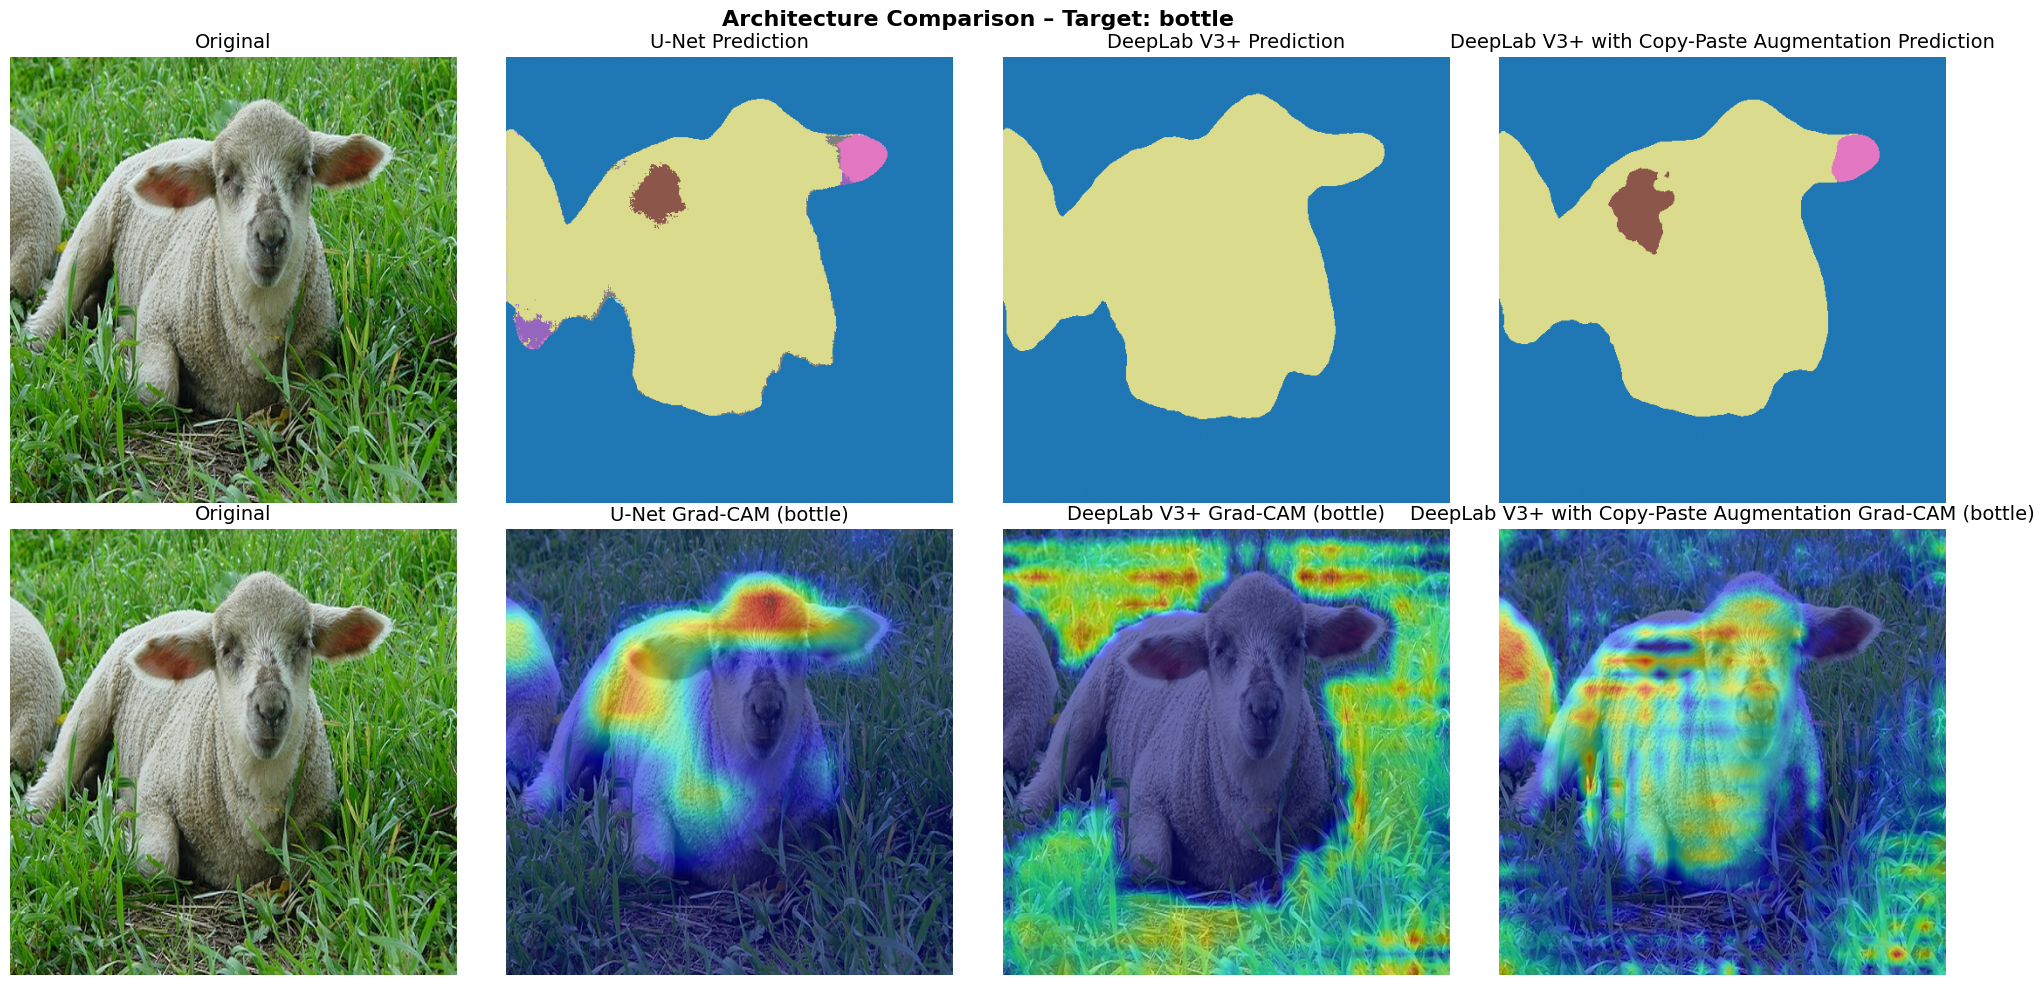

In [23]:
# Cung cấp một tấm ảnh nằm trên máy của bạn (ví dụ ảnh con mèo, hoặc con chó)
sample_image = "../data/demo_image.jpg"

if os.path.exists(sample_image) and len(models_dict) > 0:
    # Hàm tự động đánh giá và show hình
    compare_gradcam(
        image_path=sample_image,
        models_dict=models_dict,
        device=device,
        target_class=None,  # Tự động phát hiện class
        size=(512, 512),
    )
else:
    print(
        "Vui lòng tạo thư mục `data` và lưu file demo_image.jpg (hoặc sửa đường dẫn sample_image ở trên) rồi chạy lại!"
    )